# __Problem Statement__

In an era of rising urban challenges and limited law enforcement resources,
the critical question is :

❓ **How can we predict and improve crime resolution rates while
   enhancing overall public safety ?**


Crime incidents vary significantly depending on multiple environmental and operational factors such as crime severity, police response time, officer allocation, weapon involvement, population density, CCTV coverage, and prior crime history.  
Traditional crime analysis methods depend mainly upon historical reports and descriptive statistics, making it difficult to identify patterns and optimize law enforcement strategies.

This dataset empowers us to :  
   • Identify high-risk areas, times, and crime types.     
   • Analyze the impact of response time and resource allocation.   
   • Uncover patterns in repeat offending and environmental factors (lighting, CCTV).   
   • Build predictive models for crime resolution and safety index.   
   • Provide data-driven recommendations for policymakers and police departments.    

## Steps to be followed

## Step 1: Import the Required Library

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)


## Step 2: Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Admin\ML\crime_rate_and_safety_analysis_dataset.csv")
df.head()

,incident_id,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,victim_count,victim_gender,victim_age_group,injuries_reported,fatalities,financial_loss_usd,weapon_used,suspect_status,case_status,reporting_method,response_time_minutes,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,CRM0000001,2025,7,Monday,Spring,Afternoon (12pm-6pm),South Africa,Remote,30,Domestic Violence,6.0,2,Female,18-25,0,0,3006.86,Knife,Acquitted,Pending Trial,Emergency Call,9.7,4,40,Yes,No,No,Full Coverage,Partially Lit,1,69.8,Yes
1,CRM0000002,2025,10,Sunday,Spring,Morning (6am-12pm),USA,Suburban,322,Robbery,5.7,1,Male,46-55,0,0,1626.49,Unknown,Convicted,Open - Active,Emergency Call,31.6,1,128,No,No,No,Partial Coverage,Well Lit,3,52.7,No
2,CRM0000003,2021,8,Saturday,Autumn,Morning (6am-12pm),USA,Rural,72,Vandalism,4.5,1,Female,Under 18,0,0,563.27,NaN,Unknown,Open - Active,Police Station,16.3,5,108,Unknown,Yes,No,Partial Coverage,Well Lit,0,77.2,No
3,CRM0000004,2025,6,Monday,Autumn,Night (10pm-2am),France,Urban,5148,Assault,3.7,1,Female,26-35,0,0,181.99,Firearm,At Large,Open - Cold Case,Police Station,78.8,3,85,No,No,No,Partial Coverage,Partially Lit,5,41.1,No
4,CRM0000005,2024,9,Friday,Spring,Evening (6pm-10pm),Mexico,Urban,3524,Arson,2.9,1,Male,36-45,0,0,111.90,NaN,Unknown,Closed - Solved,Community Report,60.2,2,27,Unknown,No,No,Partial Coverage,Well Lit,4,45.6,Yes


## Step 3: Data Cleaning and Preprocessing

In [3]:
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Years Covered : {df['year'].min()} – {df['year'].max()}")
print(f"  Countries     : {df['country'].nunique()}")

  Dataset Shape : 10000 rows × 32 columns
  Years Covered : 2021 – 2025
  Countries     : 15


In [4]:
print("\n📋 Duplicate Records :")
print(df.duplicated().sum())

print("\n📊 Dataset Information:")
print(df.info())

print("\n📈 Statistical Summary:")
df.describe()


📋 Duplicate Records :
0

📊 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   incident_id                    10000 non-null  object 
 1   year                           10000 non-null  int64  
 2   month                          10000 non-null  int64  
 3   day_of_week                    10000 non-null  object 
 4   season                         9692 non-null   object 
 5   time_of_day                    10000 non-null  object 
 6   country                        10000 non-null  object 
 7   area_type                      9123 non-null   object 
 8   population_density_per_sqkm    10000 non-null  int64  
 9   crime_type                     10000 non-null  object 
 10  crime_severity_score           10000 non-null  float64
 11  victim_count                   10000 non-null  int64  
 12

,year,month,population_density_per_sqkm,crime_severity_score,victim_count,injuries_reported,fatalities,financial_loss_usd,response_time_minutes,officers_assigned,investigation_duration_days,prior_incidents_same_location,safety_index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2023.162600,6.384100,1154.245300,5.655550,1.694400,0.90870,0.089700,2122.313595,35.914560,3.244800,54.071100,2.475200,53.981930
std,1.342215,3.423235,1724.720676,1.927015,1.025824,1.56122,0.411182,11409.984816,28.113604,1.834669,71.876776,1.564043,16.791359
min,2021.000000,1.000000,5.000000,1.000000,1.000000,0.00000,0.000000,2.430000,2.000000,1.000000,1.000000,0.000000,15.300000
25%,2022.000000,3.000000,128.000000,4.200000,1.000000,0.00000,0.000000,84.680000,17.700000,2.000000,16.000000,1.000000,40.300000
50%,2023.000000,6.000000,466.500000,5.700000,1.000000,0.00000,0.000000,250.215000,28.300000,3.000000,32.000000,2.000000,54.150000
75%,2024.000000,9.000000,1453.000000,7.000000,2.000000,2.00000,0.000000,921.580000,44.800000,4.000000,64.000000,3.000000,67.800000
max,2025.000000,12.000000,24490.000000,10.000000,5.000000,9.00000,3.000000,492775.010000,240.000000,10.000000,1500.000000,10.000000,93.400000


In [5]:
print("\n🔍 Missing Values Count:")
missing = df.isnull().sum()
missing_p = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_p})
missing_df = missing_df[(missing_df['Missing Count'] > 0)]
print(missing_df)


🔍 Missing Values Count:
                    Missing Count  Missing %
season                        308       3.08
area_type                     877       8.77
victim_age_group              388       3.88
weapon_used                  3576      35.76
gang_related                  475       4.75
lighting_condition            220       2.20


In [6]:
df['weapon_used'].value_counts()

weapon_used
Knife           1980
Firearm         1753
Blunt Object    1025
Unknown          889
Vehicle          502
Chemical         275
Name: count, dtype: int64

In [7]:
df["weapon_used"].fillna('Unknown',inplace=True)

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

incident_id                      0
year                             0
month                            0
day_of_week                      0
season                           0
time_of_day                      0
country                          0
area_type                        0
population_density_per_sqkm      0
crime_type                       0
crime_severity_score             0
victim_count                     0
victim_gender                    0
victim_age_group                 0
injuries_reported                0
fatalities                       0
financial_loss_usd               0
weapon_used                      0
suspect_status                   0
case_status                      0
reporting_method                 0
response_time_minutes            0
officers_assigned                0
investigation_duration_days      0
repeat_offender                  0
gang_related                     0
drug_related                     0
cctv_coverage                    0
lighting_condition  

## Step 4: Exploratory Data Analysis (EDA)

### Crime Distribution by Severity

In [10]:
fig = px.histogram(df,x='crime_type',color='crime_severity_score',
                   title='Crime Distribution by Severity',text_auto=True)

fig.update_layout(xaxis_title='Crime Type',yaxis_title='Number of Crimes')
fig.show()

### Conclusion :

- We can see that **Theft** has the highest number of reported incidents, followed by **Assault** and **Robbery**, making them the most common crime types in the dataset.
- Crimes such as **Extortion, Trafficking, Kidnapping and Arson** are reported much less frequently, while crime severity varies across all crime categories.

### Year wise Crime Statistics

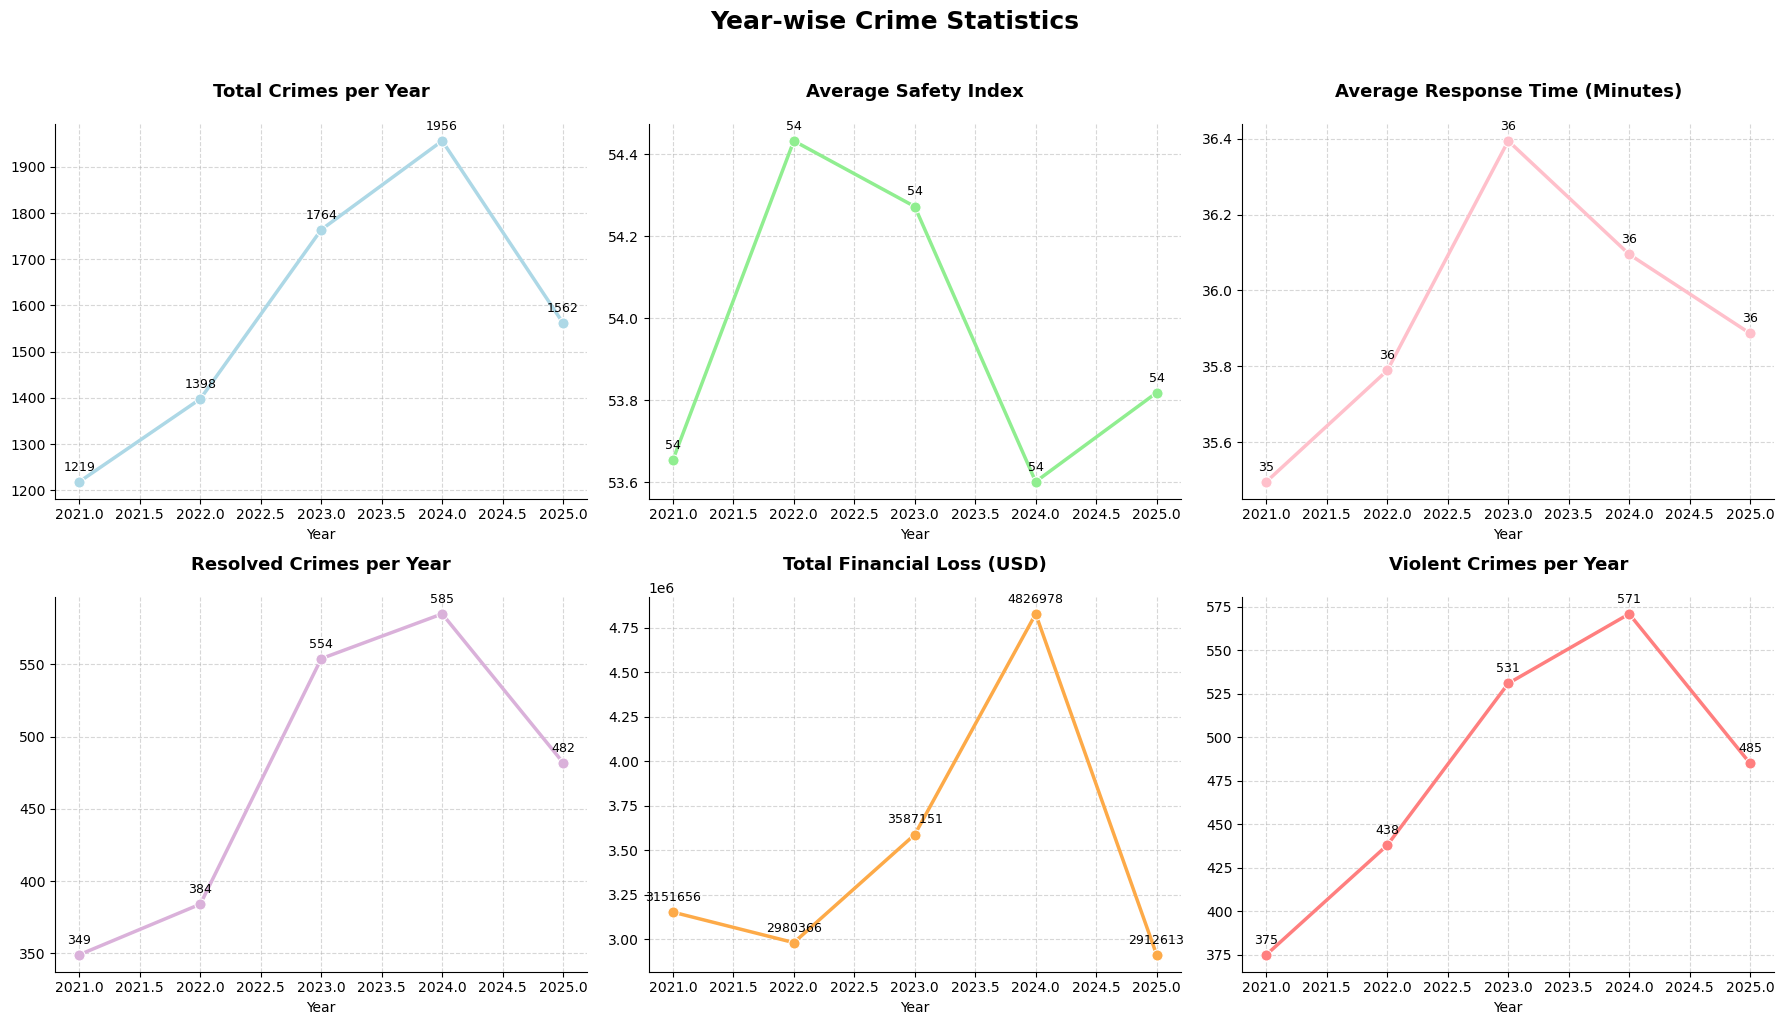

In [11]:
yearly_crimes = df.groupby('year').size()
safety_year = df.groupby('year')['safety_index'].mean()
response_year = df.groupby('year')['response_time_minutes'].mean()
resolved_year = df[df['crime_resolved'] == 'Yes'].groupby('year').size()
loss_year = df.groupby('year')['financial_loss_usd'].sum()

violent = ['Murder', 'Assault', 'Robbery', 'Sexual Assault']
violent_year = (df[df['crime_type'].isin(violent)].groupby('year').size())

plots = [
    (yearly_crimes, "Total Crimes per Year", "lightblue"),
    (safety_year, "Average Safety Index", "lightgreen"),
    (response_year, "Average Response Time (Minutes)", "pink"),
    (resolved_year, "Resolved Crimes per Year", "#DAB1DA"),
    (loss_year, "Total Financial Loss (USD)", "#FDAA48"),
    (violent_year, "Violent Crimes per Year", "#FF7F7F")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()


for ax, (data, title, color) in zip(axes, plots):

    sns.lineplot(x=data.index,y=data.values,marker='o',linewidth=2.5,markersize=8,color=color,ax=ax)

    for x, y in zip(data.index, data.values):
        ax.annotate(
            f'{y:.0f}',
            (x, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center',
            fontsize=9)

    ax.set_title(title, fontsize=13, fontweight='bold',y=1.05)
    ax.set_xlabel("Year")
    ax.set_ylabel("")
    ax.grid(True, linestyle='--', alpha=0.5)

for ax in axes:
    sns.despine(ax=ax)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
plt.suptitle("Year-wise Crime Statistics",fontsize=18,fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

### Conclusions

##### 1. Total Crimes per Year
- We can see that the total number of reported crimes increased from **2021** to **2024**, reaching the highest level in 2024.
- In **2025**, the number of crimes decreased compared to **2024**.
##### 2. Average Safety Index
- We can see that the average safety index showed minor fluctuations throughout the years.
- The highest safety index was observed in **2022**, while the lowest was observed in **2024**.
##### 3. Average Response Time (Minutes)
- We can see that the average response time increased from **2021** to **2023**, reaching the highest value in **2023**.
- After 2023, the response time gradually decreased in **2024** and **2025**.
##### 4. Resolved Crimes per Year
- We can see that the number of resolved crimes increased from **2021** to **2024**, reaching the highest level in **2024**.
- In **2025**, the number of resolved crimes decreased compared to the previous year.
##### 5. Total Financial Loss (USD)
- We can see that the total financial loss fluctuated across the years, with the highest loss recorded in **2024**.
- The financial loss decreased significantly in **2025** compared to **2024**.
##### 6. Violent Crimes per Year
- We can see that violent crimes increased from **2021** to **2024**, reaching the highest level in **2024**.
- In **2025**, violent crimes decreased compared to the previous year.

### Crime Distribution Overview

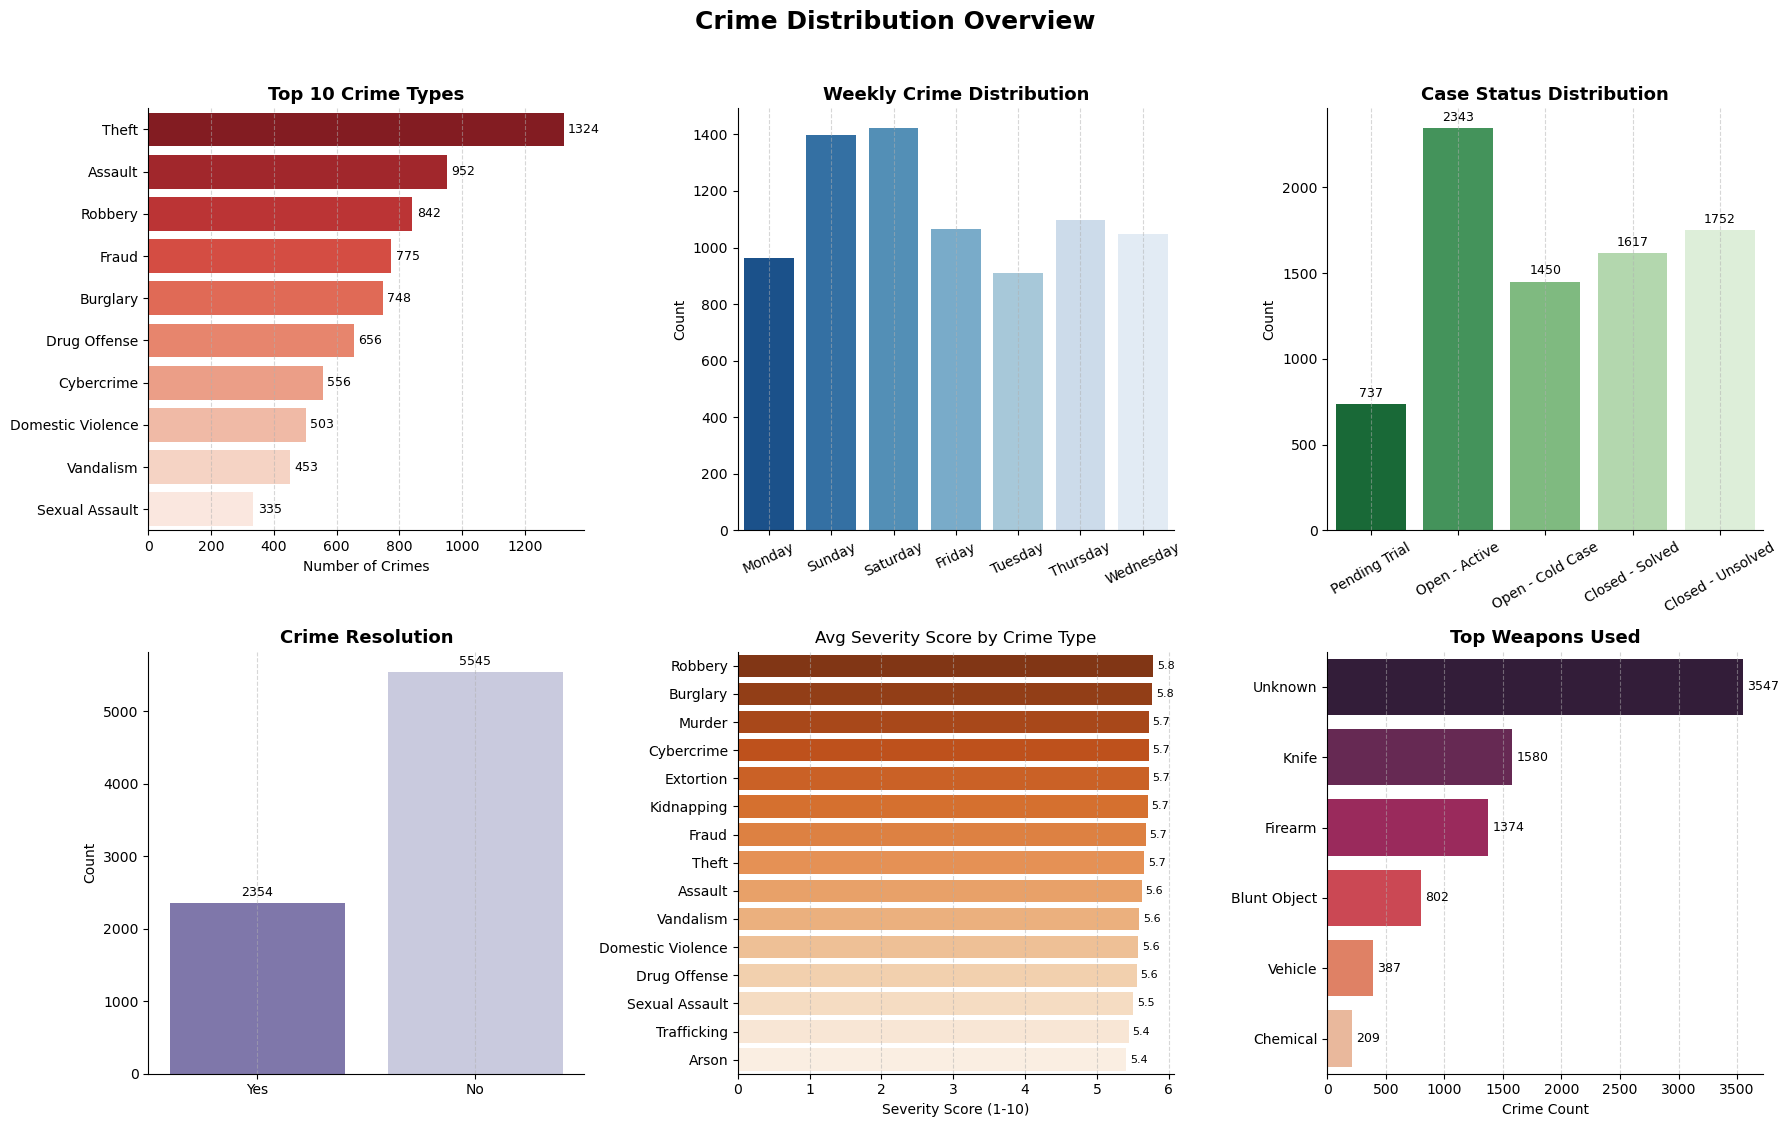

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()


def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

# 1. Top Crime Types
top_crimes = df['crime_type'].value_counts().head(10)

sns.barplot(x=top_crimes.values,y=top_crimes.index,palette='Reds_r',ax=axes[0])
axes[0].set_title("Top 10 Crime Types", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Number of Crimes")
axes[0].set_ylabel("")
add_labels(axes[0])

# 2. Weekly Crime Distribution
sns.countplot(x='day_of_week',data=df,palette='Blues_r',ax=axes[1])
axes[1].set_title("Weekly Crime Distribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=25)
add_labels(axes[4])

# 3. Case Status
sns.countplot(x='case_status',data=df,palette='Greens_r',ax=axes[2])
axes[2].set_title("Case Status Distribution", fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")
add_labels(axes[2])

# 4. Crime Resolution
sns.countplot(x='crime_resolved',data=df,palette='Purples_r',ax=axes[3])
axes[3].set_title("Crime Resolution", fontsize=13, fontweight='bold')
axes[3].set_xlabel("")
axes[3].set_ylabel("Count")
add_labels(axes[3])

# 5. Avg Severity Score by Crime Type
severity_by_crime = (df.groupby('crime_type')['crime_severity_score'].mean().sort_values(ascending=False))

sns.barplot(x=severity_by_crime.values,y=severity_by_crime.index,palette="Oranges_r",ax=axes[4])
axes[4].set_title('Avg Severity Score by Crime Type')
axes[4].set_xlabel('Severity Score (1-10)')
axes[4].set_ylabel('')

for i, v in enumerate(severity_by_crime.values):
    axes[4].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=8)

# 6. Top Weapons Used
top_weapons = df['weapon_used'].value_counts().head(8)

sns.barplot(x=top_weapons.values,y=top_weapons.index,palette='rocket',ax=axes[5])
axes[5].set_title("Top Weapons Used", fontsize=13, fontweight='bold')
axes[5].set_xlabel("Crime Count")
axes[5].set_ylabel("")
add_labels(axes[5])


for ax in axes:
    sns.despine(ax=ax)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle(
    "Crime Distribution Overview",fontsize=18,fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

### Conclusions

#### 1. Top 10 Crime Types
- We can see that **Theft** is the most common crime, followed by **Assault** and **Robbery**.
- **Sexual Assault** and **Vandalism** have comparatively fewer reported cases among the top 10 crime types.

#### 2. Victim Age Group
- We can see that crime incidents are distributed across all days of the week.
- **Saturday** and **Sunday** recorded the highest number of crime cases, while **Tuesday** recorded the lowest number of cases.

#### 3. Case Status Distribution
- We can see that **Open - Active** has the highest number of cases, followed by **Closed - Unsolved** and **Closed - Solved**.
- A significant number of cases are still open or unresolved, indicating the need for better investigation and case closure strategies.

#### 4. Crime Resolution
- We can see that a larger number of crimes remain **unresolved (No)** compared to **resolved crimes (Yes)**.
- This indicates the need to improve investigation processes and increase the crime resolution rate.

#### 5. Average Severity Score by Crime Type
- We can see that **Robbery** and **Burglary** have the highest average severity scores.
- Crimes such as **Arson** and **Trafficking** have comparatively lower average severity scores among the displayed crime types.

#### 6. Top Weapons Used
- We can see that **Unknown** is the most frequently recorded weapon category, followed by **Knife** and **Firearm**.
- **Chemical** and **Vehicle** are among the least frequently recorded weapon categories.

### Response Time vs Safety Index by Crime Resolution

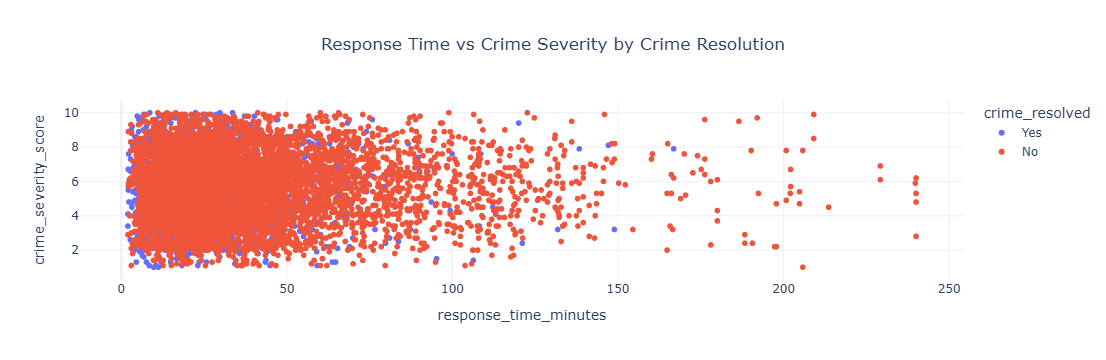

In [13]:
fig = px.scatter(
    df,
    x='response_time_minutes',
    y='crime_severity_score',
    color='crime_resolved',
    title='Response Time vs Crime Severity by Crime Resolution')

fig.update_layout(
    title_x=0.5,
    template='plotly_white'
)

fig.show()

### Conclusion

- We can see that both resolved and unresolved crimes are spread across different response times and safety index values, with a significant overlap between the two groups.
- This indicates that **response time and crime Severity alone are not sufficient to determine whether a crime will be resolved**, and other factors likely influence the outcome.

### Population Density vs Response Time by Crime Severity

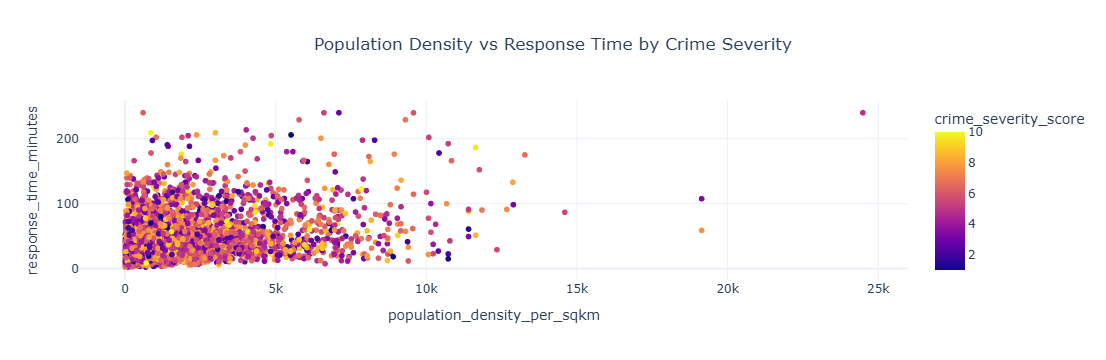

In [14]:
fig = px.scatter(
    df,
    x='population_density_per_sqkm',
    y='response_time_minutes',
    color='crime_severity_score',
    hover_name='crime_type',
    title='Population Density vs Response Time by Crime Severity')

fig.update_layout(
    title_x=0.5,
    template='plotly_white')

fig.show()

### Conclusion

- We can see that most crime incidents occur in areas with **low to moderate population density**, while only a few cases are reported in highly populated areas.
- The response time varies across all population densities, indicating that **population density alone does not strongly influence emergency response time or crime severity**.

### Victim Profile & Financial Impact Analysis

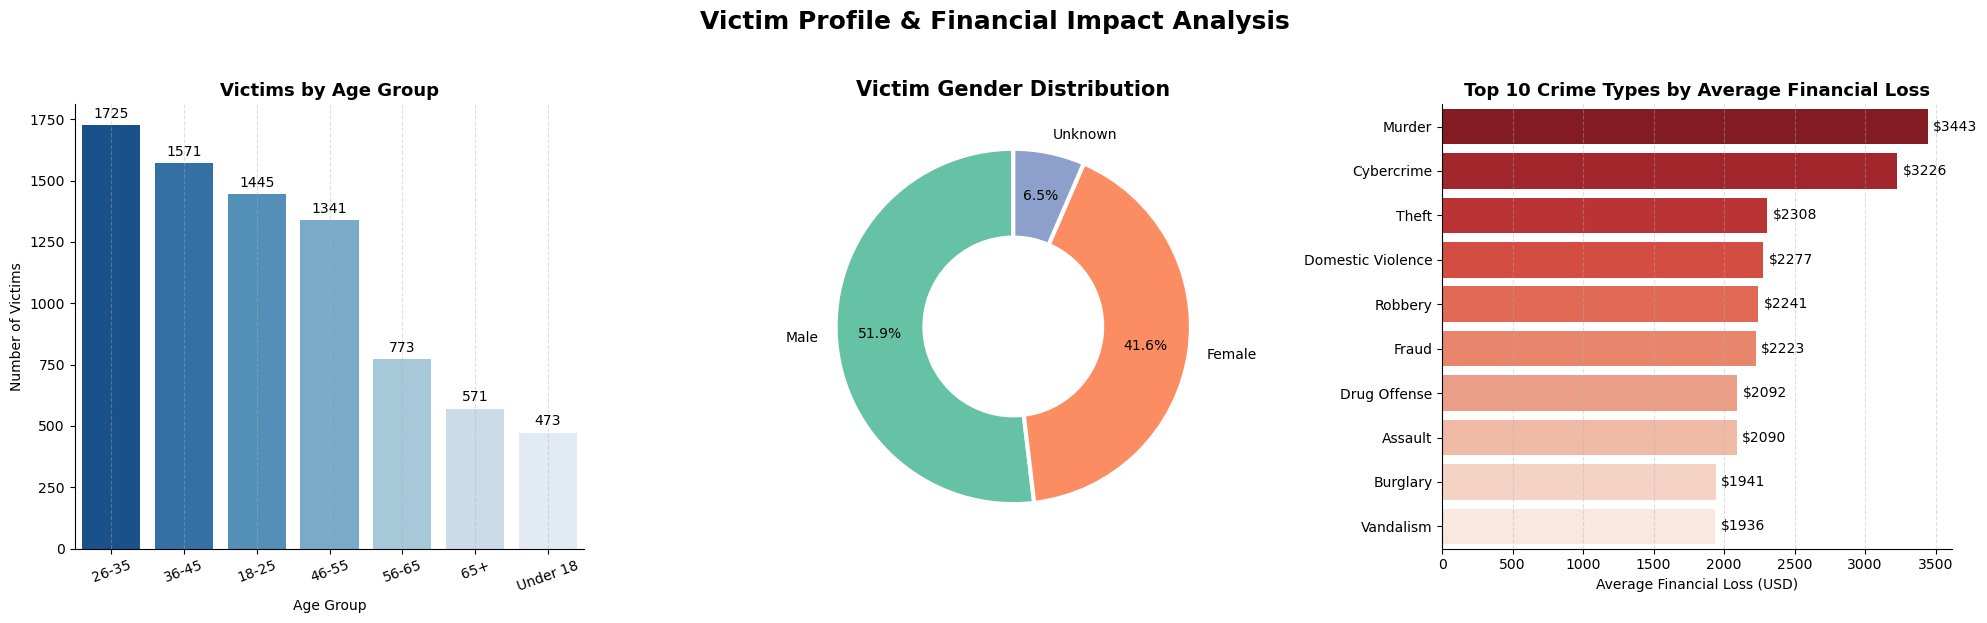

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.suptitle("Victim Profile & Financial Impact Analysis",
             fontsize=18, fontweight='bold', y=1.03)

# 1. Victims by Age Group
age_counts = df['victim_age_group'].value_counts()

sns.barplot(x=age_counts.index,y=age_counts.values,palette="Blues_r",ax=axes[0])
axes[0].set_title("Victims by Age Group", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Victims")
axes[0].tick_params(axis='x', rotation=20)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)


# 2. Victim Gender Distribution
gender_counts = df['victim_gender'].value_counts()

axes[1].pie(gender_counts.values,labels=gender_counts.index,autopct='%1.1f%%',pctdistance=0.75,startangle=90,
    wedgeprops=dict(width=0.5,edgecolor='white',linewidth=3))
axes[1].set_title("Victim Gender Distribution",fontsize=15,fontweight='bold')

            
# 3. Average Financial Loss
top_loss = (df.groupby('crime_type')['financial_loss_usd'].mean().sort_values(ascending=False).head(10))

sns.barplot(x=top_loss.values,y=top_loss.index,palette="Reds_r",ax=axes[2])
axes[2].set_title("Top 10 Crime Types by Average Financial Loss",fontsize=13, fontweight='bold')
axes[2].set_xlabel("Average Financial Loss (USD)")
axes[2].set_ylabel("")

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='$%.0f', padding=4)

for ax in [axes[0], axes[2]]:
    sns.despine(ax=ax)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Conclusions

#### 1. Victims by Age Group

- We can see that the **26–35 age group** has the highest number of crime victims, followed by the **36–45** and **18–25** age groups.
- In contrast, people **Under 18** and those aged **65+** have the fewest reported victim cases.

#### 2. Victim Gender Distribution

- We can see that **male victims slightly outnumber female victims**, while only a small percentage of victims have an unknown gender.
- This indicates that males are more frequently affected by crime in the given dataset.

#### 3. Top 10 Crime Types by Average Financial Loss

- We can see that **Murder** causes the highest average financial loss, followed by **Cybercrime** and **Theft**.
- **Burglary** and **Vandalism** have the lowest average financial loss among the top 10 crime types.

### Geographic Crime Analysis

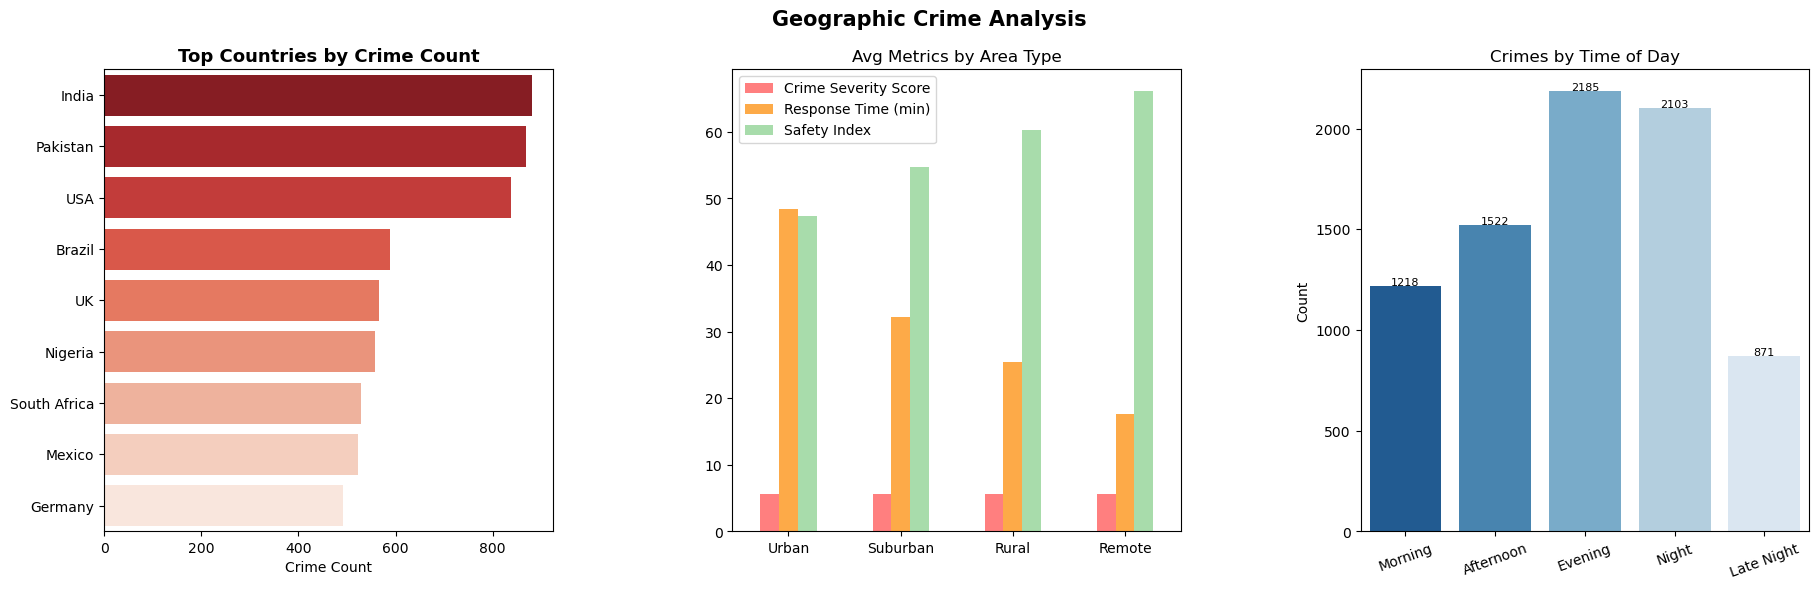

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Geographic Crime Analysis', fontsize=15, fontweight='bold')

# 1. Crimes by Country
top_countries = df['country'].value_counts().head(9)

sns.barplot(x=top_countries.values,y=top_countries.index,palette='Reds_r',ax=axes[0])
axes[0].set_title("Top Countries by Crime Count", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Crime Count")
axes[0].set_ylabel("")

# 2. Avg Metrics by Area Type
area_stats = df.groupby('area_type')[['crime_severity_score','response_time_minutes','safety_index']].mean()
area_order = ['Urban', 'Suburban', 'Rural', 'Remote']
area_stats = area_stats.reindex(area_order)

area_stats.plot(kind='bar',ax=axes[1],color=['#FF7F7F', '#FDAA48', '#A8DCAB'])
axes[1].set_title('Avg Metrics by Area Type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Crime Severity Score', 'Response Time (min)', 'Safety Index'])

# 3. Crimes by Time of Day
time_order = ['Morning (6am-12pm)','Afternoon (12pm-6pm)','Evening (6pm-10pm)','Night (10pm-2am)','Late Night (2am-6am)']
time_counts = df['time_of_day'].value_counts().reindex(time_order)

sns.barplot(x=time_counts.index,y=time_counts.values,palette="Blues_r",ax=axes[2])
axes[2].set_title('Crimes by Time of Day')
axes[2].set_xlabel('')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Morning', 'Afternoon', 'Evening', 'Night', 'Late Night'],rotation=20)

for i, v in enumerate(time_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=8)

plt.subplots_adjust(wspace=0.4)
plt.show()

### Conclusions

#### 1. Top Countries by Crime Count

- We can see that **India** has the highest number of reported crimes, followed closely by **Pakistan** and the **USA**.
- Countries such as **Germany** and **Mexico** have comparatively fewer reported crime incidents in the dataset.

#### 2. Average Metrics by Area Type

-We can see that **Urban areas** have the highest average response time, while **Remote areas** have the lowest average response time.
- The average **Safety Index** increases from **Urban** to **Remote** areas, while the average **Crime Severity Score** remains fairly similar across all area types.

#### 3. Crimes by Time of Day

- We can see that most crimes occur during the **Evening** and **Night**, while **Late Night** records the fewest incidents.
- This suggests that crime activity is generally higher during the later hours of the day.

### Correlation Heatmap

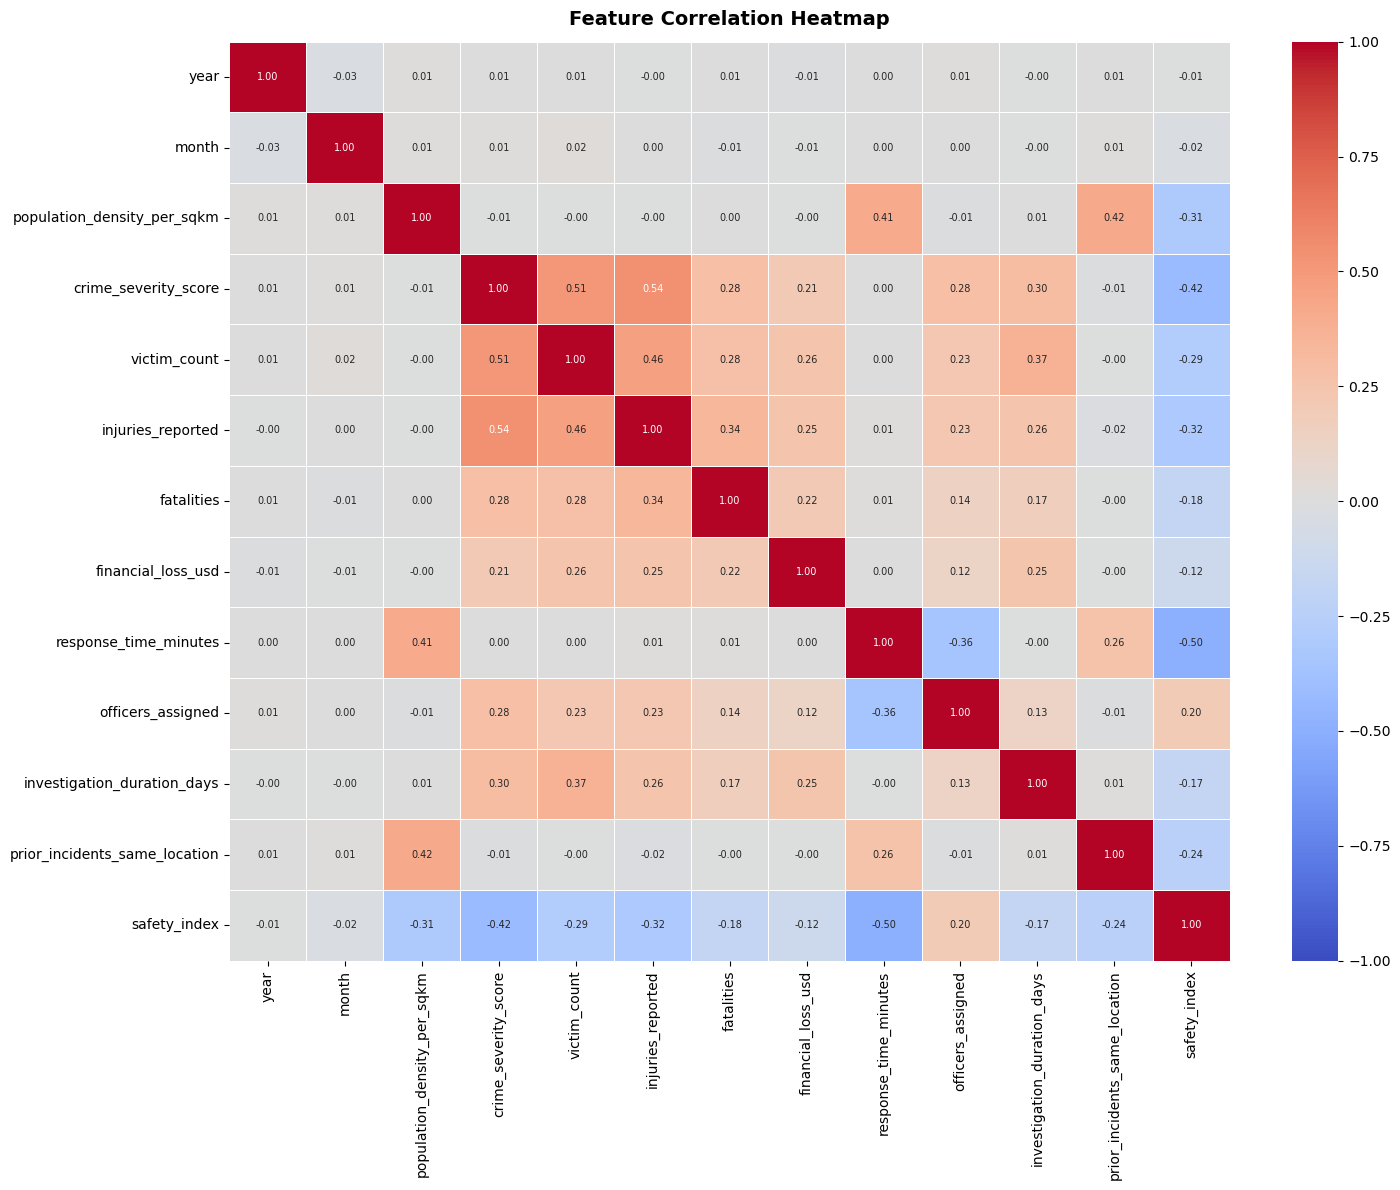

In [17]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr     = df[num_cols].corr()

fig, ax  = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size':7},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

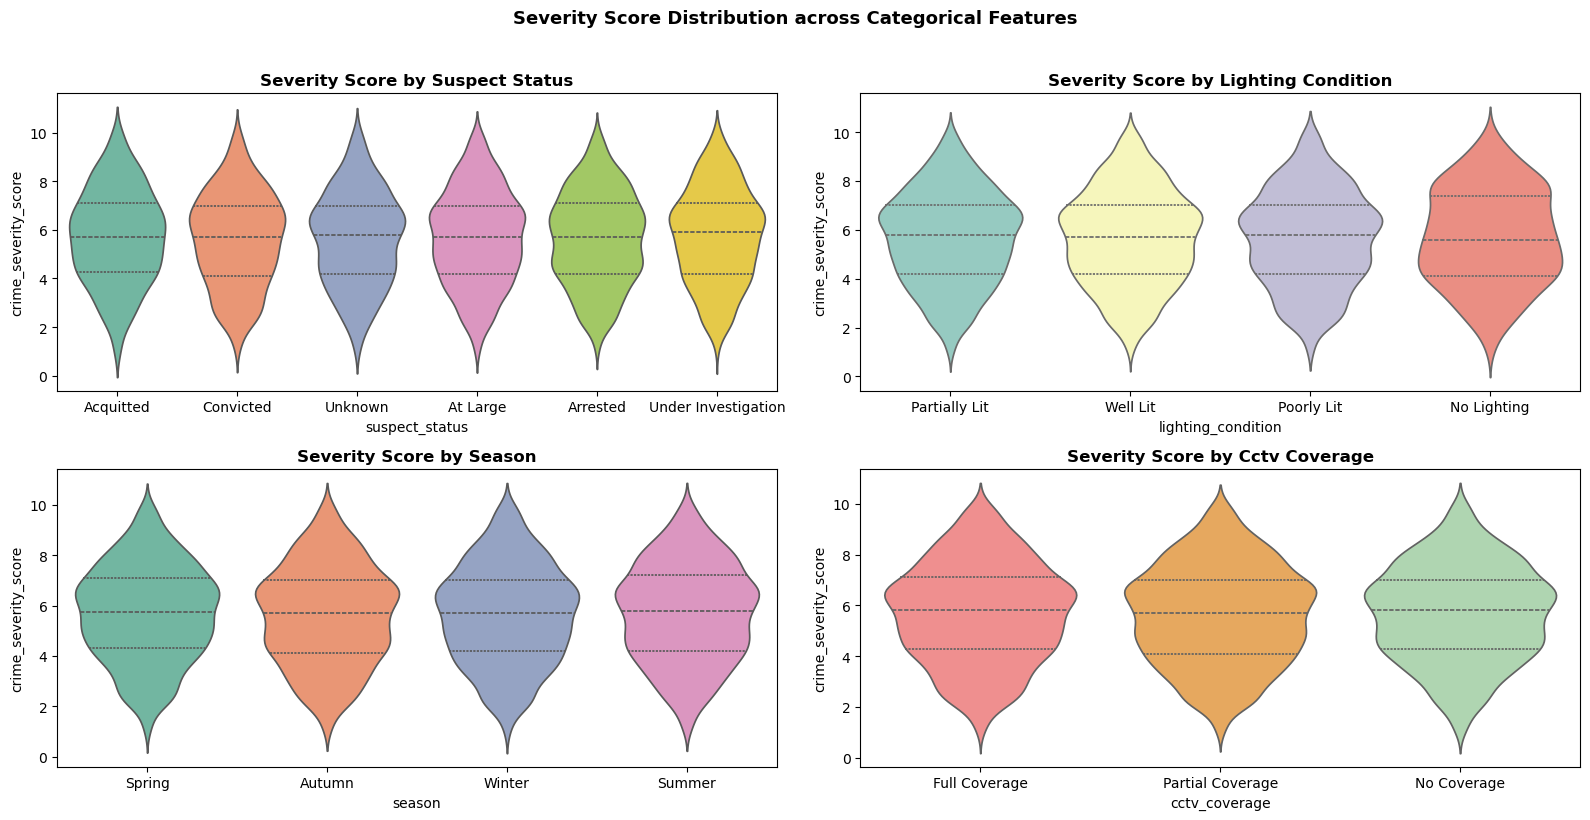

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.ravel()

# suspect_status
sns.violinplot(data=df, x='suspect_status', y='crime_severity_score',
               ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('Severity Score by Suspect Status', fontweight='bold')

# lighting_condition
sns.violinplot(data=df, x='lighting_condition', y='crime_severity_score',
               ax=axes[1], palette='Set3', inner='quartile')
axes[1].set_title('Severity Score by Lighting Condition', fontweight='bold')

# season
sns.violinplot(data=df, x='season', y='crime_severity_score',
               ax=axes[2], palette='Set2', inner='quartile')
axes[2].set_title('Severity Score by Season', fontweight='bold')

# cctv_coverage
sns.violinplot(data=df, x='cctv_coverage', y='crime_severity_score',
               ax=axes[3], palette=['#FF7F7F','#FDAA48','#A8DCAB'], inner='quartile')
axes[3].set_title('Severity Score by Cctv Coverage', fontweight='bold')

plt.suptitle('Severity Score Distribution across Categorical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Feature–Target Separation

In [19]:
features = ['country','area_type','crime_type','crime_severity_score','weapon_used',
            'cctv_coverage','gang_related','lighting_condition','suspect_status']

df['crime_resolved'] = df['crime_resolved'].map({'No': 0,'Yes': 1})

x=df[features]
y=df["crime_resolved"]

### Encoding Categorical Features

In [20]:
x = pd.get_dummies(x, drop_first=True, dtype=int)

### Training and Testing the Features

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 6 : Model Initialization & Model Training

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42,max_depth=10,min_samples_leaf=5),
    "Random Forest": RandomForestClassifier(n_estimators=300,max_depth=12,
                     min_samples_split=10,min_samples_leaf=4,random_state=42,n_jobs=-1)
}

In [23]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred,average="weighted"), 4),
        "Recall": round(recall_score(y_test, y_pred,average="weighted"), 4),
        "F1 Score": round(f1_score(y_test, y_pred,average="weighted"), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values(by=["F1 Score", "ROC AUC"], ascending=False)
)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.7614,0.7486,0.7614,0.7493,0.8010
Random Forest,0.7620,0.7500,0.7620,0.7365,0.7895
Decision Tree,0.7310,0.7201,0.7310,0.7238,0.7458


In [24]:
model=LogisticRegression(max_iter=1000,random_state=42)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred=model.predict(x_test)

### Confusion Matrix

In [26]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[984 125]
 [252 219]]


In [27]:
acc = accuracy_score(y_test,y_pred)
print('accuracy:{:.2f}%'.format(acc*100))
print(classification_report(y_test, y_pred))

accuracy:76.14%
              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1109
           1       0.64      0.46      0.54       471

    accuracy                           0.76      1580
   macro avg       0.72      0.68      0.69      1580
weighted avg       0.75      0.76      0.75      1580



## Step 7: Hyperparameter Tuning using GridSearchCV

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs'],
    'class_weight':[None,'balanced']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train,y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation ROC-AUC:", grid.best_score_)

Best Parameters: {'C': 100, 'class_weight': None, 'solver': 'lbfgs'}
Best Cross Validation ROC-AUC: 0.7599307706184792


In [29]:
y_pred = best_model.predict(x_test)

acc = accuracy_score(y_test,y_pred)
print('accuracy:{:.2f}%'.format(acc*100))
print(classification_report(y_test, y_pred))

accuracy:76.14%
              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1109
           1       0.64      0.47      0.54       471

    accuracy                           0.76      1580
   macro avg       0.72      0.68      0.69      1580
weighted avg       0.75      0.76      0.75      1580



In [30]:
import joblib

package = {
    "model": best_model,
    "columns": x_train.columns.tolist()
}

joblib.dump(package, r"C:\Users\Admin\ML\Model Deployment\crime_resolution_model.pkl")

['C:\\Users\\Admin\\ML\\Model Deployment\\crime_resolution_model.pkl']